# Electricity NPV summary

Run the electricity Monte Carlo mean NPV, deterministic NPV, and Monte Carlo ranking summaries. This notebook displays figures inline only; it does not save figures or CSV files.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_deterministic import calculate_deterministic_electricity_results
from electricity.electricity_npv_monte_carlo import DEFAULT_RANDOM_SEED, DEFAULT_SAMPLE_SIZE, simulate_electricity_results
from electricity.electricity_npv_summary_figures import (
    ELECTRICITY_NPV_SCALE_OPTIONS,
    ELECTRICITY_TECHNOLOGY_LABELS,
    calculate_electricity_npv_rankings_from_results,
)
from npv_summary_plots import plot_average_rank_bars, plot_mean_npv_technology_bars


## Settings

In [2]:
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
TECHNOLOGIES = tuple(ELECTRICITY_TECHNOLOGY_LABELS)
NPV_SCALE = "MEUR"  # "MEUR" or "EUR/MWh"

if NPV_SCALE not in ELECTRICITY_NPV_SCALE_OPTIONS:
    raise ValueError(f"Unknown NPV_SCALE: {NPV_SCALE!r}")

NPV_CONFIG = ELECTRICITY_NPV_SCALE_OPTIONS[NPV_SCALE]
NPV_METRIC_COLUMN = str(NPV_CONFIG["metric_column"])
NPV_SCALE_FACTOR = float(NPV_CONFIG["scale"])
NPV_SUMMARY_COLUMN = str(NPV_CONFIG["summary_column"])
NPV_AXIS_LABEL = str(NPV_CONFIG["axis_label"])
NPV_RANKING_LABEL = str(NPV_CONFIG["ranking_label"])

pd.options.display.float_format = "{:,.3f}".format


## Monte Carlo mean NPV

,label,npv_m_eur,median,p05,p95
7,PV,196.903,196.906,112.600,281.880
6,Wind Onshore,146.028,145.946,35.277,257.141
5,Wind Offshore,77.422,77.877,-64.329,218.535
2,CCGT,-325.203,-297.295,-809.018,62.287
3,CCGT + CCS,-424.159,-393.594,-990.609,35.953
0,Hard coal,-728.265,-722.333,-872.449,-604.015
1,Hard coal+CCS,-784.634,-785.062,"-1,068.769",-503.672
4,Nuclear,"-1,534.331","-1,531.903","-2,385.854",-686.372
8,Biogas,"-2,615.921","-2,615.796","-2,960.069","-2,270.004"


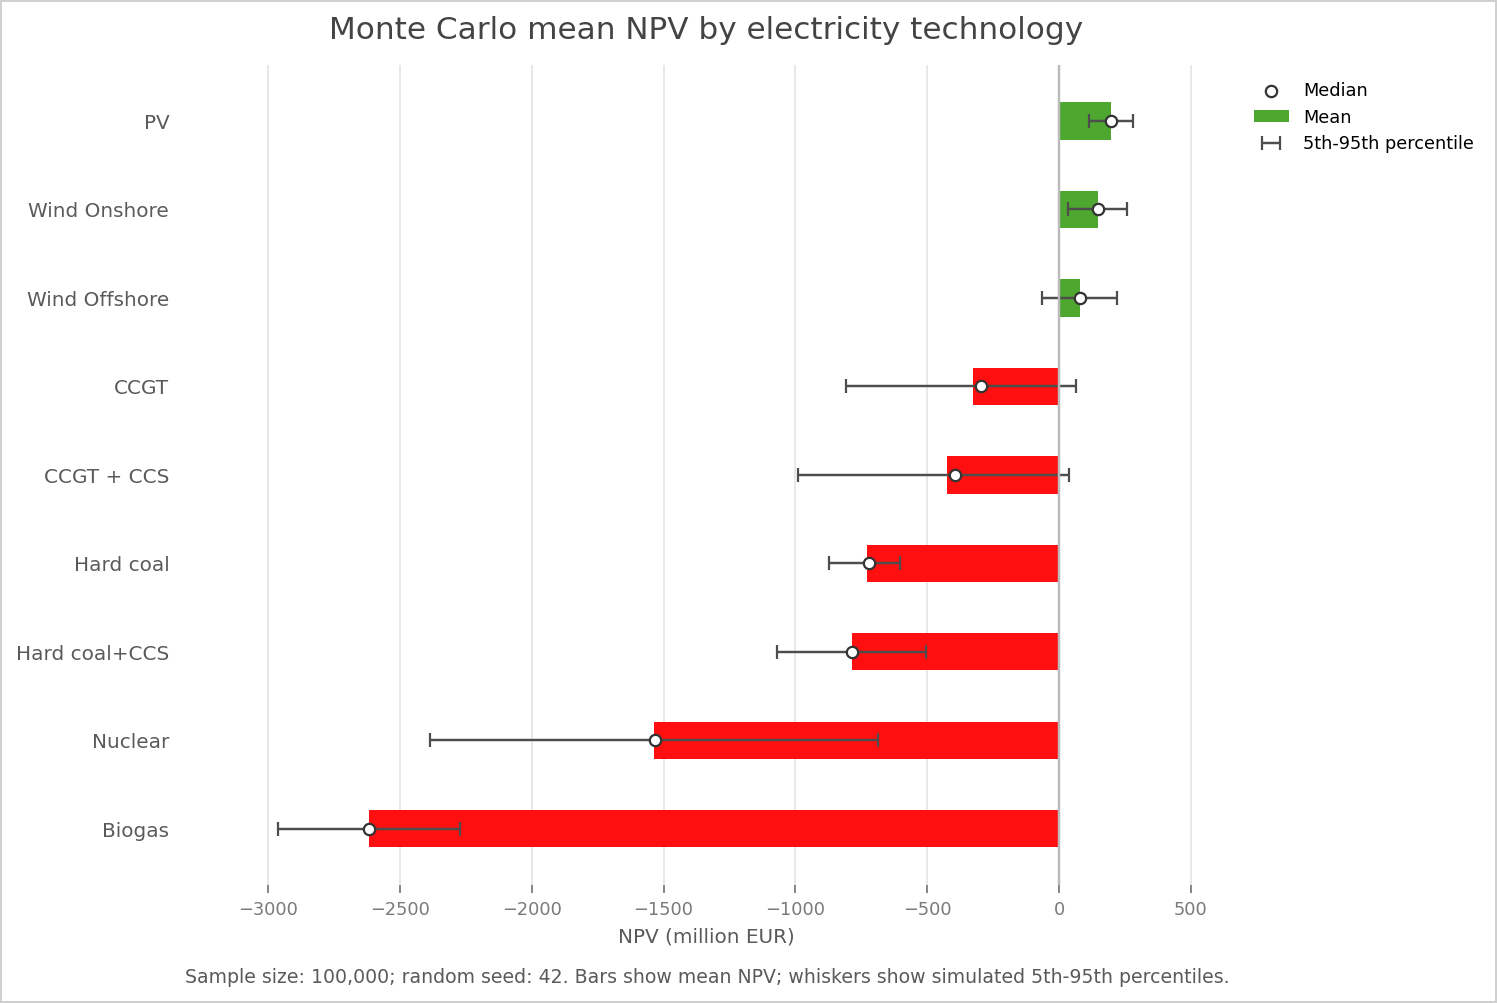

In [3]:
monte_carlo_results = simulate_electricity_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=TECHNOLOGIES,
)

mc_summary_rows = []
for technology, results in monte_carlo_results.items():
    values = np.asarray(results[NPV_METRIC_COLUMN], dtype=float) / NPV_SCALE_FACTOR
    mc_summary_rows.append(
        {
            "label": ELECTRICITY_TECHNOLOGY_LABELS.get(technology, technology),
            NPV_SUMMARY_COLUMN: values.mean(),
            "median": np.median(values),
            "p05": np.percentile(values, 5),
            "p95": np.percentile(values, 95),
        }
    )
mc_summary = pd.DataFrame(mc_summary_rows).sort_values(NPV_SUMMARY_COLUMN, ascending=False)
mc_summary_by_label = mc_summary.set_index("label")

display(mc_summary)
plot_mean_npv_technology_bars(
    values_million_eur=mc_summary_by_label[NPV_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Monte Carlo mean {NPV_RANKING_LABEL} by electricity technology",
    median_values_million_eur=mc_summary_by_label["median"].to_dict(),
    lower_values_million_eur=mc_summary_by_label["p05"].to_dict(),
    upper_values_million_eur=mc_summary_by_label["p95"].to_dict(),
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    x_axis_label=NPV_AXIS_LABEL,
)
plt.show()


## Deterministic NPV

,label,npv_m_eur
7,PV,201.477
6,Wind Onshore,152.816
5,Wind Offshore,83.371
2,CCGT,-320.194
3,CCGT + CCS,-422.908
0,Hard coal,-719.220
1,Hard coal+CCS,-766.473
4,Nuclear,"-1,525.725"
8,Biogas,"-2,589.063"


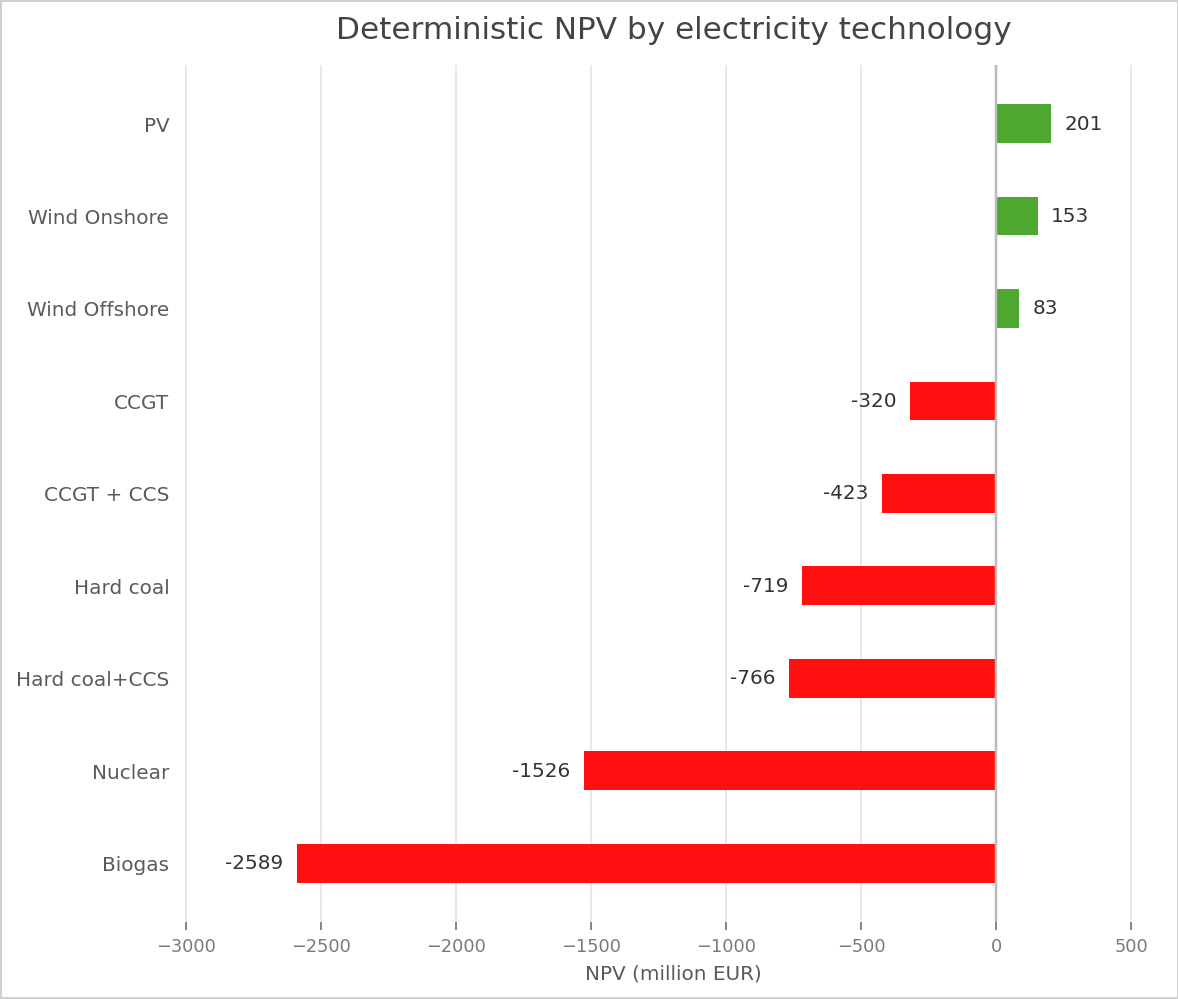

In [4]:
deterministic_results = calculate_deterministic_electricity_results(technologies=TECHNOLOGIES)
det_summary_rows = []
for technology, results in deterministic_results.items():
    det_summary_rows.append(
        {
            "label": ELECTRICITY_TECHNOLOGY_LABELS.get(technology, technology),
            NPV_SUMMARY_COLUMN: float(np.asarray(results[NPV_METRIC_COLUMN]).item()) / NPV_SCALE_FACTOR,
        }
    )
det_summary = pd.DataFrame(det_summary_rows).sort_values(NPV_SUMMARY_COLUMN, ascending=False)

display(det_summary)
plot_mean_npv_technology_bars(
    values_million_eur=det_summary.set_index("label")[NPV_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Deterministic {NPV_RANKING_LABEL} by electricity technology",
    x_axis_label=NPV_AXIS_LABEL,
)
plt.show()


## Monte Carlo NPV ranking

,Technology,Average rank,Probability rank 1,Probability top 3,Simulations
0,PV,1.455,0.624,0.998,100000
1,Wind Onshore,2.026,0.272,0.983,100000
2,Wind Offshore,2.668,0.102,0.934,100000
3,CCGT,4.238,0.001,0.053,100000
4,CCGT + CCS,5.186,0.002,0.032,100000
5,Hard coal,6.189,0.000,0.000,100000
6,Hard coal+CCS,6.469,0.000,0.000,100000
7,Nuclear,7.787,0.000,0.000,100000
8,Biogas,8.982,0.000,0.000,100000


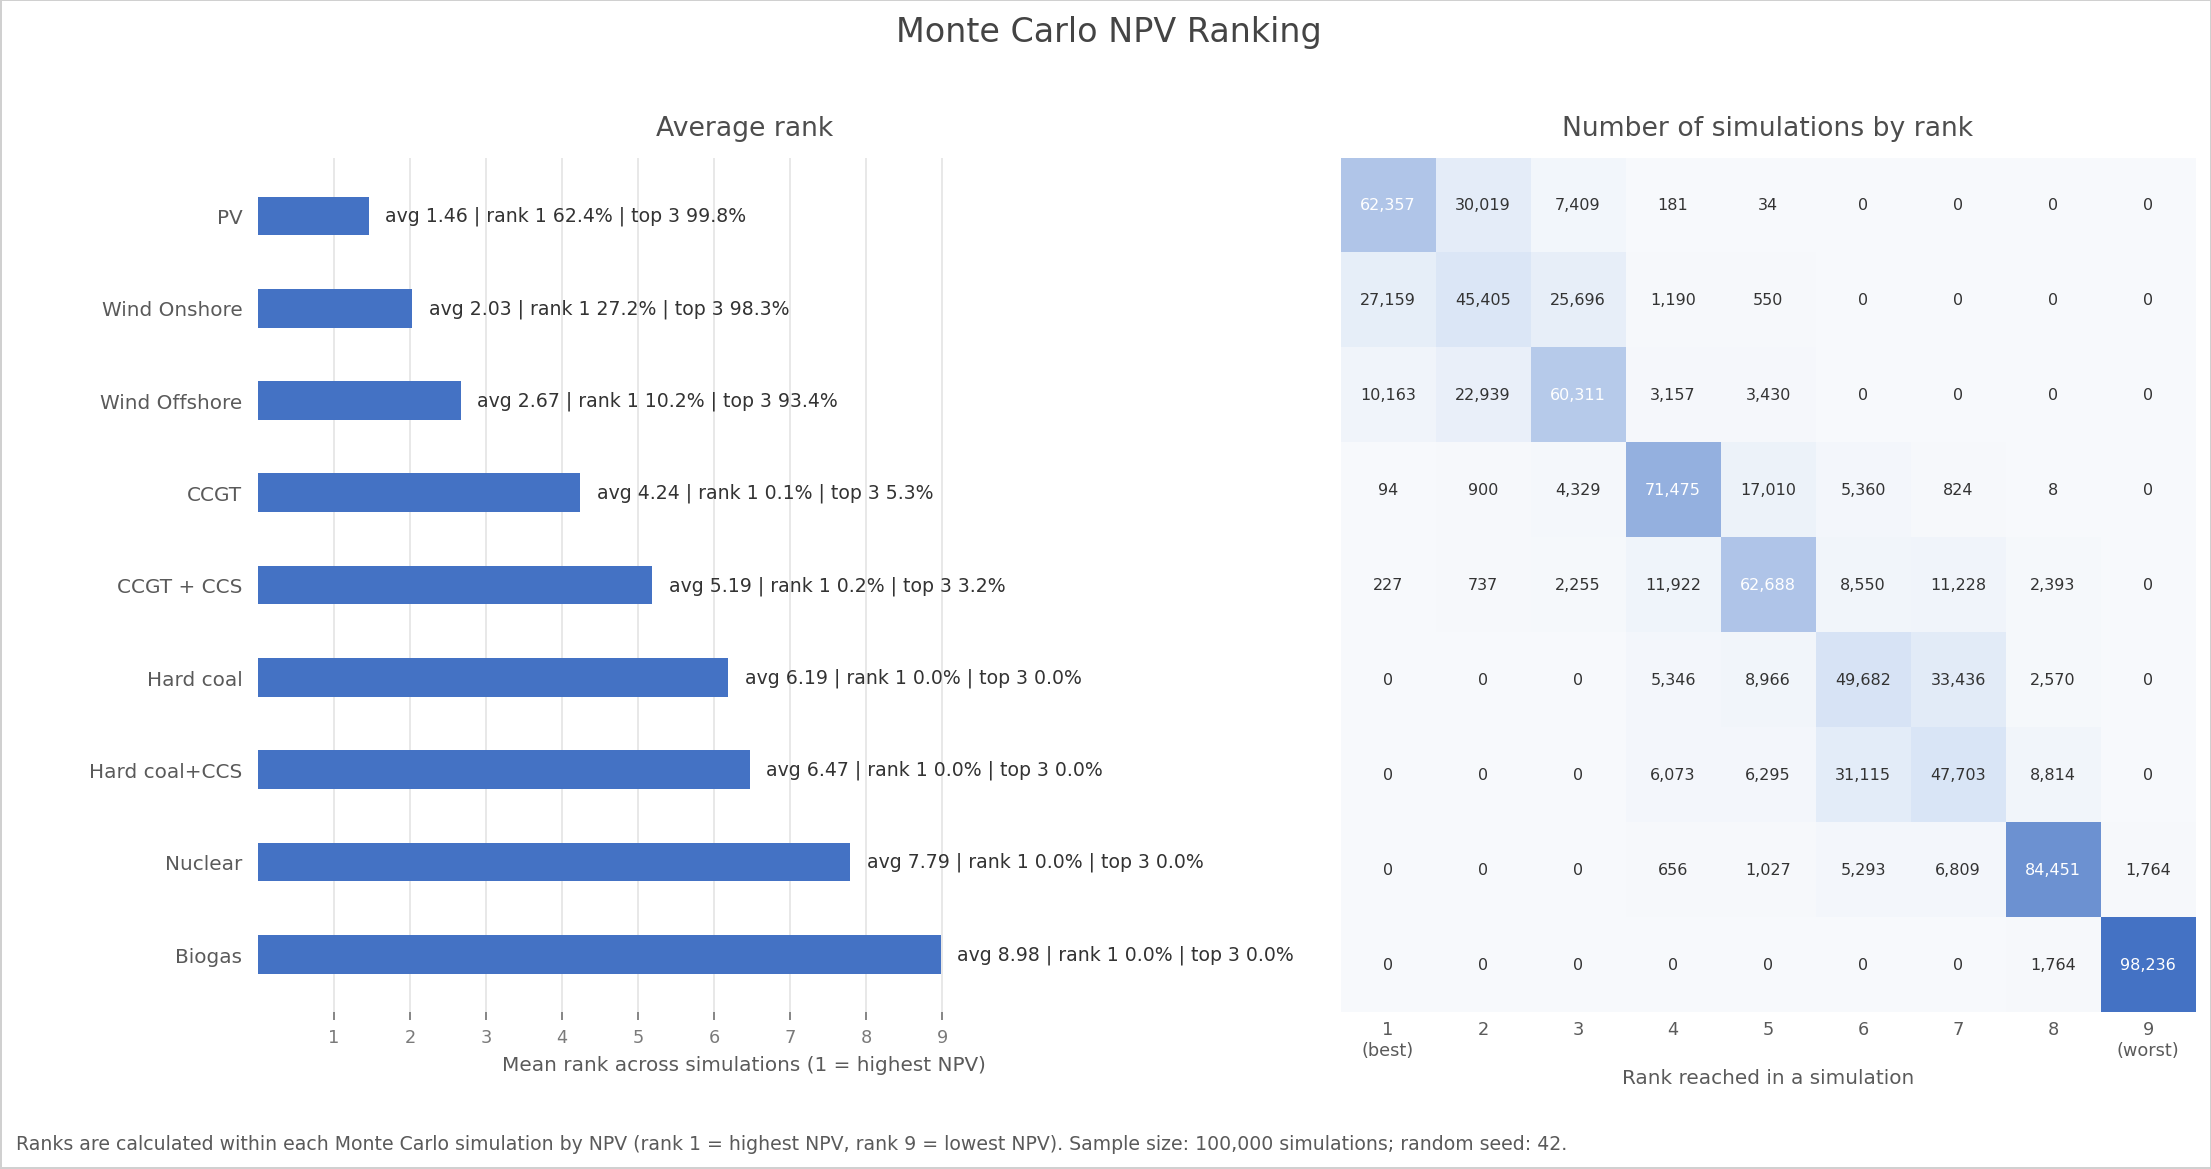

In [5]:
ranking_raw, ranking_summary = calculate_electricity_npv_rankings_from_results(
    results=monte_carlo_results,
    sector_name="Electricity",
    npv_scale=NPV_SCALE,
)

ranking_summary_for_plot = ranking_summary.assign(
    display_label=ranking_summary["technology"].map(ELECTRICITY_TECHNOLOGY_LABELS).fillna(ranking_summary["technology"])
)
rank_table = (
    ranking_summary_for_plot.rename(columns={"display_label": "Technology"})
    .loc[:, ["Technology", "average_rank", "probability_rank_1", "probability_top_3", "n_simulations"]]
    .rename(
        columns={
            "average_rank": "Average rank",
            "probability_rank_1": "Probability rank 1",
            "probability_top_3": "Probability top 3",
            "n_simulations": "Simulations",
        }
    )
)
display(rank_table)
plot_average_rank_bars(
    ranking_summary=ranking_summary_for_plot,
    output_path=None,
    title=f"Monte Carlo {NPV_RANKING_LABEL} Ranking",
    random_seed=RANDOM_SEED,
)
plt.show()
